[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/Time-Series-Analysis/blob/main/notebooks/EN/chapter0_seminar_notebook.ipynb)

# Time Series Analysis — Seminar 0: First Steps with Time Series

*Seminar notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- The seminar comes before the Chapter 0 lecture: the definitions are in the primer below.
- **[Solved]** exercises show the full code and output: use them as models. **[Proposed]** exercises have an empty code cell: solve them yourself; the solutions are discussed in class. Nothing is handed in.

> The solutions are discussed in the seminar.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [ ]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/TSA/Chapter_0'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


In [ ]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import optimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [ ]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import tsa_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the TSA repository; EUR/RON is the official BNR reference rate.
- Macroeconomic series: FRED (St. Louis Fed), Eurostat and the classic data sets of statsmodels.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [ ]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/Time-Series-Analysis/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the TSA repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years


def read_fred(ids, start=None, end=None):
    """FRED series (St. Louis Fed) from the public fredgraph CSV, e.g. read_fred('UNRATE') or
    read_fred(['GDPC1', 'CPIAUCSL']). Returns a Series (one id) or a DataFrame (several ids)."""
    one = isinstance(ids, str)
    ids = [ids] if one else list(ids)
    out = []
    for sid in ids:
        key = ('fred', sid)
        if key not in _CACHE:
            url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={sid}'
            t = pd.read_csv(url, index_col=0, parse_dates=True, na_values='.')
            _CACHE[key] = pd.to_numeric(t.iloc[:, 0], errors='coerce').rename(sid)
        out.append(_CACHE[key])
    df = pd.concat(out, axis=1).loc[start:end]
    df.index.name = 'date'
    return df.iloc[:, 0].dropna() if one else df


def _eurostat_period(p):
    p = str(p)
    if '-Q' in p:
        y, q = p.split('-Q')
        return pd.Timestamp(int(y), 3 * int(q) - 2, 1)
    if '-' in p and len(p) == 7:
        return pd.Timestamp(p + '-01')
    if len(p) == 4:
        return pd.Timestamp(int(p), 1, 1)
    return pd.Timestamp(p)


def read_eurostat(dataset, key, start=None):
    """One Eurostat series from the public SDMX 2.1 API (SDMX-CSV), e.g. Romanian quarterly real GDP,
    seasonally and calendar adjusted, chain-linked volumes (2010) in million EUR:
        read_eurostat('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
    `key` is the dot-separated series key of the dataset (dimensions in the order of the dataset)."""
    url = (f'https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/{dataset}/{key}?format=SDMX-CSV'
           + (f'&startPeriod={start}' if start else ''))
    ck = ('eurostat', url)
    if ck not in _CACHE:
        t = pd.read_csv(url)
        s = pd.Series(pd.to_numeric(t['OBS_VALUE'], errors='coerce').values,
                      index=[_eurostat_period(p) for p in t['TIME_PERIOD']], name=f'{dataset}:{key}')
        s.index.name = 'date'
        _CACHE[ck] = s.sort_index().dropna()
    return _CACHE[ck]


def load_statsmodels(name):
    """Classic data sets shipped with statsmodels (offline): 'sunspots' (yearly, 1700-2008), 'co2' (weekly,
    Mauna Loa, 1958-2001), 'macrodata' (US quarterly macro, 1959-2009), 'nile' (yearly Nile flow, 1871-1970)."""
    import statsmodels.api as sm
    if name == 'sunspots':
        d = sm.datasets.sunspots.load_pandas().data
        s = d.set_index(pd.to_datetime(d['YEAR'].astype(int).astype(str)))['SUNACTIVITY']
        s.index.name = 'date'
        return s.rename('sunspots')
    if name == 'co2':
        return sm.datasets.co2.load_pandas().data['co2'].rename('co2')
    if name == 'macrodata':
        d = sm.datasets.macrodata.load_pandas().data
        d.index = pd.period_range('1959Q1', periods=len(d), freq='Q').to_timestamp()
        d.index.name = 'date'
        return d
    if name == 'nile':
        d = sm.datasets.nile.load_pandas().data
        s = d.set_index(pd.to_datetime(d['year'].astype(int).astype(str)))['volume']
        s.index.name = 'date'
        return s.rename('nile')
    raise KeyError(f'unknown statsmodels data set: {name}')

## Setup

### Primer

- Growth over one period: $100(y_t/y_{t-1} - 1)$; over a year: $100(y_t/y_{t-m} - 1)$, with $m = 4$ for quarterly and $m = 12$ for monthly data; log difference $100(\ln y_t - \ln y_{t-1})$.
- Sample autocorrelation $r_k = \sum_{t>k}(y_t-\bar y)(y_{t-k}-\bar y) / \sum_t (y_t-\bar y)^2$; band $\pm 1.96/\sqrt T$.
- Naive forecast $\hat y_{T+h} = y_T$; seasonal naive $\hat y_{T+h} = y_{T+h-m}$.
- Split by time into a training set and a test set; MAE $= \frac1h\sum|e|$, RMSE $= \sqrt{\frac1h\sum e^2}$.

### Seminar functions

In [ ]:
GDP_NSA = ('namq_10_gdp', 'Q.CLV10_MEUR.NSA.B1GQ.RO')
HICP = ('prc_hicp_minr', 'M.I15.TOTAL.RO')
ELEC = ('nrg_cb_pem', 'M.TOTAL.GWH.RO')
START = '2015-01-01'


def growth_rates(y, m):
    """Period-on-period growth 100(y_t / y_{t-1} - 1), growth over m periods 100(y_t / y_{t-m} - 1) and the
    log difference 100(ln y_t - ln y_{t-1}), all in %."""
    y = pd.Series(y, dtype=float)
    return pd.DataFrame({'y': y, 'pop': 100 * (y / y.shift(1) - 1), 'yoy': 100 * (y / y.shift(m) - 1),
                         'dlog': 100 * np.log(y).diff()})


def sample_acf(x, nlags):
    """Sample autocorrelations r_1..r_nlags (the sum of products of deviations divided by the sum of squares)."""
    x = np.asarray(x, dtype=float)
    d = x - x.mean()
    return np.array([np.sum(d[k:] * d[:-k]) / np.sum(d * d) for k in range(1, nlags + 1)])


def paper_forecasts(train, test, m):
    """Naive and seasonal naive forecasts of the test values, their errors, MAE and RMSE."""
    train, test = np.asarray(train, float), np.asarray(test, float)
    h = len(test)
    out = {}
    for name, fc in [('naive', np.repeat(train[-1], h)), ('snaive', np.array([train[len(train) - m + (i % m)] for i in range(h)]))]:
        e = test - fc
        out[name] = {'fc': fc, 'e': e, 'mae': float(np.mean(np.abs(e))), 'rmse': float(np.sqrt(np.mean(e ** 2)))}
    return out


def gdp_growth():
    """Romanian real GDP (billion EUR, 2010 prices, unadjusted): quarter-on-quarter and year-on-year growth."""
    g = read_eurostat(*GDP_NSA) / 1000
    g.index = pd.PeriodIndex(g.index, freq='Q').to_timestamp()
    d = growth_rates(g.values, 4)
    d.index = g.index
    return d


def fig_gdp_growth(d, name='ch0_sem_b1_growth', save=True):
    x = d.loc['2010':]
    fig, ax = plt.subplots(figsize=(10, 4.0))
    ax.plot(x.index, x['pop'], color=st.MainBlue, lw=1.2, marker='o', ms=2.5, label='Quarter on quarter, %')
    ax.plot(x.index, x['yoy'], color=st.IDAred, lw=1.8, label='Year on year (same quarter a year earlier), %')
    ax.axhline(0, color=st.DarkText, lw=0.6)
    ax.set_ylabel('%')
    st.legend_outside_bottom(ax, ncol=2, y=-0.12)
    st.check_no_grey(fig)
    if save:
        st.save_fig(name)
    else:
        plt.show()


def eurron_acf(nlags=20):
    """EUR/RON reference rate since START: ACF of the level and of the daily log returns (%)."""
    s = load_close('eurron', START)
    r = 100 * np.log(s).diff().dropna()
    return {'level': s, 'ret': r, 'acf_level': sample_acf(s, nlags), 'acf_ret': sample_acf(r, nlags),
            'band_level': 1.96 / np.sqrt(len(s)), 'band_ret': 1.96 / np.sqrt(len(r))}


def fig_acf_pair(a, b, band_a, band_b, lab_a, lab_b, name, col_a=st.Forest, col_b=st.MainBlue, save=True):
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
    for ax, acf, band, lab, col in [(axes[0], a, band_a, lab_a, col_a), (axes[1], b, band_b, lab_b, col_b)]:
        k = np.arange(1, len(acf) + 1)
        ax.vlines(k, 0, acf, color=col, lw=2.2, label=lab)
        ax.axhline(0, color=st.DarkText, lw=0.6)
        ax.axhspan(-band, band, color=st.MainBlue, alpha=0.12, lw=0)
        ax.set_xlabel('Lag $k$')
        ax.set_ylim(-0.5, 1.05)
    axes[0].set_ylabel('Sample autocorrelation $r_k$')
    st.fig_legend_bottom(fig, ncol=2, y=0.0)
    fig.tight_layout(rect=(0, 0.08, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig(name)
    else:
        plt.show()


def hicp_rates():
    """Romanian HICP since START: monthly (m/m) and annual (y/y) inflation in %."""
    h = read_eurostat(*HICP)
    h.index = pd.PeriodIndex(h.index, freq='M').to_timestamp()
    d = growth_rates(h.values, 12)
    d.index = h.index
    return d.loc[START:]


def electricity():
    e = read_eurostat(*ELEC) / 1000
    e.index = pd.PeriodIndex(e.index, freq='M').to_timestamp()
    return e


def fig_elec_forecast(train, test, out, name='ch0_sem_b4_forecast', save=True):
    fig, ax = plt.subplots(figsize=(10, 4.0))
    tail = train.iloc[-36:]
    ax.plot(tail.index, tail, color=st.MainBlue, lw=1.3, label='Training data')
    ax.plot(test.index, test, color=st.DarkText, lw=1.8, label='Test data (actual)')
    ax.plot(out['naive']['fc'].index, out['naive']['fc'], color=st.Amber, ls='--', lw=1.5, label='Naive')
    ax.plot(out['snaive']['fc'].index, out['snaive']['fc'], color=st.Forest, ls='--', lw=1.5, label='Seasonal naive')
    ax.set_ylabel('TWh per month')
    st.legend_outside_bottom(ax, ncol=4, y=-0.12)
    st.check_no_grey(fig)
    if save:
        st.save_fig(name)
    else:
        plt.show()

### Setup check

- Romanian real GDP, quarterly, unadjusted, billion EUR (Eurostat revises its data: small differences in the last value are normal).

In [ ]:
g = read_eurostat('namq_10_gdp', 'Q.CLV10_MEUR.NSA.B1GQ.RO') / 1000
print(len(g), g.index[0].date(), g.index[-1].date())
print(g.tail(2).round(1))
g.plot()
plt.show()

## A1 [Solved]: Growth rates

**Question:** did the Romanian economy collapse in the first quarter of 2025? **Inputs:** real GDP, billion EUR: 38.7, 45.6, 52.8, 59.2 (2024 Q1–Q4), 38.9, 46.8 (2025 Q1–Q2).

1. Compute the quarter-on-quarter growth rates.
2. Compute the year-on-year growth rates for 2025 Q1 and Q2.
3. Compute the log difference for 2025 Q1 and compare it with the quarter-on-quarter rate.

**Report:** the two kinds of growth rates and one sentence that answers the question.

In [7]:
# Solution
a1 = growth_rates([38.7, 45.6, 52.8, 59.2, 38.9, 46.8], 4)
a1.round(2)

,y,pop,yoy,dlog
0,38.7,NaN,NaN,NaN
1,45.6,17.83,NaN,16.41
2,52.8,15.79,NaN,14.66
3,59.2,12.12,NaN,11.44
4,38.9,-34.29,0.52,-41.99
5,46.8,20.31,2.63,18.49


**Interpretation:** the fall of a third from Q4 to Q1 happens every winter; compared with a year earlier, GDP grew.

## A2 [Solved]: An autocorrelation by hand

**Inputs:** $y = 2, 4, 3, 5, 4, 6$.

1. Compute the mean and the deviations.
2. Compute the sums of squares and of products.
3. Compute $r_1$, $r_2$ and the band $\pm 1.96/\sqrt T$.

In [8]:
# Solution
x = np.array([2, 4, 3, 5, 4, 6], dtype=float)
d = x - x.mean()
print('mean:', x.mean(), ' sum of squares:', (d ** 2).sum(), ' sum of lag-1 products:', (d[1:] * d[:-1]).sum())
print('r1, r2:', sample_acf(x, 2).round(3), ' band:', round(1.96 / np.sqrt(len(x)), 3))

mean: 4.0  sum of squares: 10.0  sum of lag-1 products: -1.0
r1, r2: [-0.1  0.4]  band: 0.8


**Interpretation:** both values lie inside the band: 6 observations are too few to detect memory.

## A3 [Solved]: Naive forecasts and their errors

**Inputs:** training set 10, 14, 18, 12, 11, 15, 20, 13; test set 12, 16, 21, 14; $m = 4$.

1. Write the naive and the seasonal naive forecasts.
2. Compute the errors.
3. Compute the MAE and the RMSE.

In [9]:
# Solution
a3 = paper_forecasts([10, 14, 18, 12, 11, 15, 20, 13], [12, 16, 21, 14], 4)
for k, v in a3.items():
    print(k, 'forecasts', v['fc'], 'errors', v['e'], 'MAE', v['mae'], 'RMSE', round(v['rmse'], 2))

naive forecasts [13. 13. 13. 13.] errors [-1.  3.  8.  1.] MAE 3.25 RMSE 4.33
snaive forecasts [11. 15. 20. 13.] errors [1. 1. 1. 1.] MAE 1.0 RMSE 1.0


**Interpretation:** the seasonal naive forecast keeps the seasonal pattern and wins.

## B1 [Solved]: Romanian GDP

**Question:** which growth rate should be reported for an unadjusted quarterly series?

1. Compute the quarter-on-quarter and the year-on-year growth rates.
2. Plot the two rates since 2010.
3. Count the negative values of each rate; compute the average q/q growth of the first quarters.
4. Interpretation: which of the two rates shows the recessions?

negative q/q: 32 of 125
negative y/y: 28 of 122
average q/q growth of the first quarters, %: -36.3
                y    pop   yoy   dlog
date                                 
2026-01-01  38.37 -34.34 -1.49 -42.07
2026-04-01  45.88  19.58 -1.94  17.88


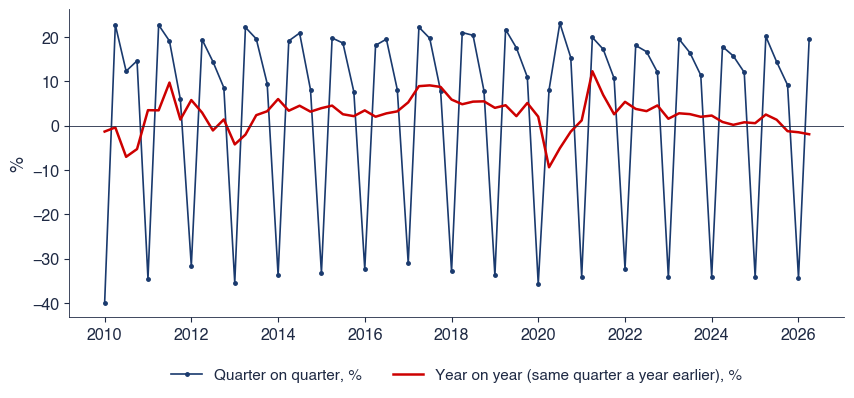

In [10]:
# Solution
d = gdp_growth()
print('negative q/q:', int((d['pop'] < 0).sum()), 'of', int(d['pop'].notna().sum()))
print('negative y/y:', int((d['yoy'] < 0).sum()), 'of', int(d['yoy'].notna().sum()))
print('average q/q growth of the first quarters, %:', round(d['pop'][d.index.quarter == 1].mean(), 1))
print(d.tail(2).round(2))
fig_gdp_growth(d, save=False)

**Interpretation:** only the year-on-year rate shows the recessions (2009–2010, 2020) and the slowdown of 2025–2026; for unadjusted data, report year-on-year growth.

## B2 [Solved]: EUR/RON, memory of levels and of changes

1. Compute the daily log returns.
2. Compute the ACF of the level and of the returns for lags 1–20.
3. Compare $r_1$ of the returns with the band and count the lags outside it.
4. Interpretation: is the naive forecast a sensible benchmark for the exchange rate?

level: r1 0.999  r20 0.971
returns: r1 0.078  r2 -0.0003  band 0.036
lags outside the band: 8


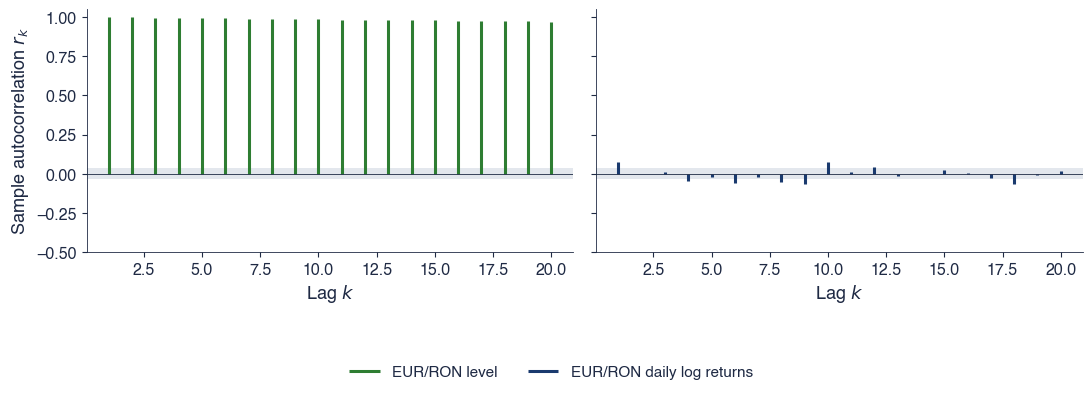

In [11]:
# Solution
b2 = eurron_acf()
print('level: r1', round(b2['acf_level'][0], 3), ' r20', round(b2['acf_level'][-1], 3))
print('returns: r1', round(b2['acf_ret'][0], 3), ' r2', round(b2['acf_ret'][1], 4), ' band', round(b2['band_ret'], 3))
print('lags outside the band:', int((np.abs(b2['acf_ret']) > b2['band_ret']).sum()))
fig_acf_pair(b2['acf_level'], b2['acf_ret'], b2['band_level'], b2['band_ret'], 'EUR/RON level', 'EUR/RON daily log returns', 'ch0_sem_b2_acf', save=False)

**Interpretation:** today's level is the best simple forecast of tomorrow's level; past changes add very little, so the naive forecast is the benchmark to beat.

## A4 [Proposed]: New numbers

**Model:** A1, A2 and A3 [Solved]. **Inputs:** the quarterly series 120, 150, 132, 168, 126; the series 5, 7, 6, 8, 9; a series with $m = 3$: training 20, 30, 25, 22, 32, 27, test 23, 33, 29.

1. Compute the growth rates, the log differences and the year-on-year rate of the last quarter.
2. Compute $r_1$ of the series 5, 7, 6, 8, 9 and the band.
3. Compute the MAE and RMSE of the naive and seasonal naive forecasts.

In [ ]:
# Your code here


## B3 [Proposed]: Romanian inflation

**Model:** B1 and B2 [Solved]. Use `hicp_rates()` (monthly HICP since 2015; columns `pop` = m/m, `yoy` = y/y).

1. Compute the monthly and the annual inflation rates.
2. Compute the average monthly inflation for each calendar month.
3. Compute the ACF of the monthly rate for lags 1–24 and of the annual rate at lag 1.
4. Interpretation: why is the annual rate so persistent?

In [ ]:
# Your code here


## B4 [Proposed]: Electricity, naive or seasonal naive?

**Model:** A3 [Solved]. Use `electricity()` (TWh per month).

1. Split by time: the last 24 months form the test set.
2. Forecast the test set with the naive and the seasonal naive method ($m = 12$).
3. Compute the MAE and RMSE and plot both forecasts against the test data.
4. Interpretation: why does the seasonal naive method not win clearly here?

In [ ]:
# Your code here


## C2 [Proposed]: Critique an AI answer

**Prompt** sent to an AI assistant: *From the quarterly Romanian real GDP, compute the average annual growth rate and the RMSE of a naive forecast.* The AI's code is below; it runs without an error message. Its conclusion: *forecasting GDP is hopeless.*

**Model:** A1, A3 and B1 [Solved].

1. Run the AI's code and read its output.
2. Find the three errors planted in the code.
3. For each error, say how you would detect it.
4. Write the corrected code, with the last 8 quarters as the test set, and report the corrected numbers.
5. Say whether the conclusion survives.

In [ ]:
# The AI's answer (do not edit this cell)
g = read_eurostat('namq_10_gdp', 'Q.CLV10_MEUR.NSA.B1GQ.RO') / 1000
growth = g.diff()                                # annual growth rate, %
print('average annual growth:', growth.mean())
test = g.sample(frac=0.2, random_state=1).sort_index()   # test set
train = g.drop(test.index)                               # training set
fc = train.reindex(g.index).ffill().shift(1).reindex(test.index)  # naive
rmse = ((test - fc) ** 2).mean()
print('RMSE of the naive forecast:', rmse)

In [ ]:
# Your code here
